In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [2]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [00:16<00:00, 180MB/s]



In [3]:
!unzip new-plant-diseases-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/273a7a9e-18be-4b6a-976a-fa5ffd69b731___RS_HL 4366_90deg.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/275f8963-f4f4-4903-962b-1da716725d08___RS_HL 4780_90deg.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/275f8963-f4f4-4903-962b-1da716725d08___RS_HL 4780_new30degFlipLR.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/27c2aaa4-de4b-4fb1-ba8d-14d4b24b2afa___RS_HL 4665.JPG  
  inflating: new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid/Strawberry___healthy/27c2aaa4-de4b-4fb1-ba8d-14d4b24b2afa___RS_HL 4665_270deg.JPG  
  inflating: new plant diseases dataset(augmented)/New 

In [4]:
!ls "/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"


train  valid


#importing libraries

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


Data Preprocessing
Training Image preprocessing


In [6]:
training_set = tf.keras.utils.image_dataset_from_directory(
    directory = '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True,
)


Found 70295 files belonging to 38 classes.


Validation Image Preprocessing


In [7]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    directory = '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True,
)


Found 17572 files belonging to 38 classes.


In [8]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [9]:
for x,y in training_set: # x is value of each pixel and y is label(that image belongs to which class)
  print(x,x.shape)
  print(y,y.shape)
  break

tf.Tensor(
[[[[ 77.25  74.25  83.25]
   [149.75 146.75 155.75]
   [147.25 144.25 153.25]
   ...
   [152.5  154.5  167.5 ]
   [155.5  157.5  170.5 ]
   [153.75 155.75 168.75]]

  [[ 75.25  73.25  81.25]
   [154.   151.   160.  ]
   [152.75 149.75 158.75]
   ...
   [154.25 156.25 169.25]
   [155.   157.   170.  ]
   [151.5  153.5  166.5 ]]

  [[ 75.25  73.25  81.25]
   [156.   153.   162.  ]
   [153.75 150.75 159.75]
   ...
   [155.5  157.5  170.5 ]
   [155.5  157.5  170.5 ]
   [151.5  153.5  166.5 ]]

  ...

  [[ 30.75  21.25  19.25]
   [ 31.5   20.5   16.5 ]
   [ 37.25  26.25  22.25]
   ...
   [ 73.75  71.75  76.75]
   [ 73.    71.    76.  ]
   [ 72.75  70.75  75.75]]

  [[ 32.    22.5   20.5 ]
   [ 34.    23.    19.  ]
   [ 37.    23.    20.  ]
   ...
   [ 74.75  72.75  77.75]
   [ 73.5   71.5   76.5 ]
   [ 72.5   70.5   75.5 ]]

  [[ 32.75  23.25  21.25]
   [ 35.25  24.25  20.25]
   [ 35.25  21.25  18.25]
   ...
   [ 77.    75.    80.  ]
   [ 75.25  73.25  78.25]
   [ 74.25  72.25  7

###To avoid overshooting loss
1.Choose small learning rate default 0.001 we are taking 0.0001      
2.There may be chance of underfitting . so increase number of neuron      
3.Add more convolutional layer to extract more features from image , there may be possibility that model unable to capture relevant feature or model is confusing due to lack of feature so feed with more feature


#Building Model


In [10]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [11]:
model = Sequential()


In [12]:

model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

model.add(Dropout(0.25)) #Drop 25% unnecessary features from the layer we are getting to avoid overfitting
model.add(Flatten())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
#hidden layer
model.add(Dense(units=1500,activation='relu'))
model.add(Dropout(0.40))
#output layer
model.add(Dense(units=38,activation='softmax'))

In [14]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

#model training

In [16]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=20)

Epoch 1/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 166s 67ms/step - accuracy: 0.5844 - loss: 1.4161 - val_accuracy: 0.8312 - val_loss: 0.5398
Epoch 2/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 134s 61ms/step - accuracy: 0.8560 - loss: 0.4553 - val_accuracy: 0.9029 - val_loss: 0.3005
Epoch 3/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 145s 62ms/step - accuracy: 0.9113 - loss: 0.2751 - val_accuracy: 0.8969 - val_loss: 0.3140
Epoch 4/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 139s 63ms/step - accuracy: 0.9382 - loss: 0.1891 - val_accuracy: 0.9319 - val_loss: 0.2245
Epoch 5/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 140s 64ms/step - accuracy: 0.9541 - loss: 0.1394 - val_accuracy: 0.9431 - val_loss: 0.1798
Epoch 6/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 142s 64ms/step - accuracy: 0.9647 - loss: 0.1078 - val_accuracy: 0.9550 - val_loss: 0.1489
Epoch 7/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 148s 67ms/step - accuracy: 0.9700 - loss: 0.0903 - val_accuracy: 0.9513 - val_loss: 0.1604
Epoch 8/20
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 139s 63ms/step - accuracy: 

#Model Evaluation on training set

In [17]:
train_loss,train_acc = model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 57s 26ms/step - accuracy: 0.9969 - loss: 0.0093


In [18]:
print(train_loss,train_acc)

0.009311150759458542 0.9969130158424377


In [19]:
val_loss,val_acc = model.evaluate(validation_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.9736 - loss: 0.1137


In [20]:
print(val_loss,val_acc)

0.11369326710700989 0.9735943675041199


In [22]:
##saving model
model.save("trained_model.h5")#h5 model takes more space than keras model

In [23]:
training_history.history

{'accuracy': [0.584351658821106,
  0.8559641242027283,
  0.9113165736198425,
  0.9382317662239075,
  0.9540507793426514,
  0.9646774530410767,
  0.9699978828430176,
  0.9762998819351196,
  0.9786471128463745,
  0.981492280960083,
  0.9834412336349487,
  0.9844228029251099,
  0.9877516031265259,
  0.9877658486366272,
  0.9879649877548218,
  0.9894729256629944,
  0.9899850487709045,
  0.9898428320884705,
  0.9911088943481445,
  0.9921900629997253],
 'loss': [1.4160698652267456,
  0.4553048014640808,
  0.2751047611236572,
  0.18906418979167938,
  0.13942928612232208,
  0.10782014578580856,
  0.09027598053216934,
  0.07232280820608139,
  0.06652574241161346,
  0.05657739192247391,
  0.049066148698329926,
  0.048120930790901184,
  0.039901141077280045,
  0.03920600563287735,
  0.03797941282391548,
  0.03302180767059326,
  0.03230138123035431,
  0.03188187628984451,
  0.028544997796416283,
  0.024675754830241203],
 'val_accuracy': [0.8312087655067444,
  0.9028568267822266,
  0.89688140153884

In [24]:
#Recording history in json
import json
with open("training_hist.json","w") as f:
  json.dump(training_history.history,f)

#Accuracy visualisation

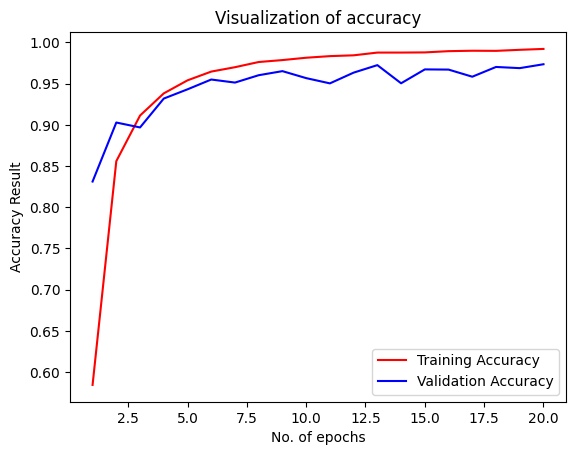

In [26]:
epochs = [i for i in range(1,21)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel("No. of epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of accuracy")
plt.legend()
plt.show()

#Some other metrics for model evaluation


In [27]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [29]:
test_set = tf.keras.utils.image_dataset_from_directory(
    directory = '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [30]:
y_pred = model.predict(test_set)
y_pred,y_pred.shape


550/550 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step


(array([[1.00000000e+00, 2.29857178e-09, 7.87291968e-11, ...,
         4.53562511e-15, 1.44797206e-13, 4.85280049e-14],
        [9.99917150e-01, 2.11162088e-09, 2.02095580e-11, ...,
         5.39698393e-14, 1.33186702e-12, 7.97654145e-15],
        [1.00000000e+00, 1.47318315e-13, 1.23508085e-14, ...,
         1.10223610e-20, 2.03597356e-18, 4.20535381e-17],
        ...,
        [1.21284851e-12, 2.56257563e-16, 8.15884795e-13, ...,
         1.54278700e-14, 1.96663284e-15, 1.00000000e+00],
        [1.90080479e-10, 1.31075545e-14, 3.57658014e-10, ...,
         4.25026377e-12, 2.07384045e-12, 1.00000000e+00],
        [3.52813760e-20, 3.12527657e-22, 7.49310088e-19, ...,
         4.90195051e-24, 4.05488654e-20, 1.00000000e+00]], dtype=float32),
 (17572, 38))

In [31]:
predicted_categories = tf.argmax(y_pred,axis=1) #axis=1 means column wise choose max value
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [32]:
true_categories = tf.concat([y for x,y in test_set],axis=0)
true_categories


<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [33]:
y_true = tf.argmax(true_categories,axis=1)
y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [34]:
from sklearn .metrics import classification_report,confusion_matrix
print(classification_report(y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.96      0.97      0.97       504
                                 Apple___Black_rot       0.99      0.99      0.99       497
                          Apple___Cedar_apple_rust       0.98      0.98      0.98       440
                                   Apple___healthy       0.99      0.96      0.98       502
                               Blueberry___healthy       0.99      0.96      0.98       454
          Cherry_(including_sour)___Powdery_mildew       0.96      1.00      0.98       421
                 Cherry_(including_sour)___healthy       0.99      0.99      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.96      0.84      0.90       410
                       Corn_(maize)___Common_rust_       0.98      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.91      0.98      0.

In [35]:
cn = confusion_matrix(y_true,predicted_categories)
print(cn)
cn.shape

[[490   1   0 ...   0   0   0]
 [  1 491   0 ...   0   0   0]
 [  0   0 433 ...   2   0   0]
 ...
 [  0   0   0 ... 489   0   0]
 [  0   0   0 ...   0 445   0]
 [  1   0   1 ...   0   0 474]]


(38, 38)

#Confusion matrix visualisation

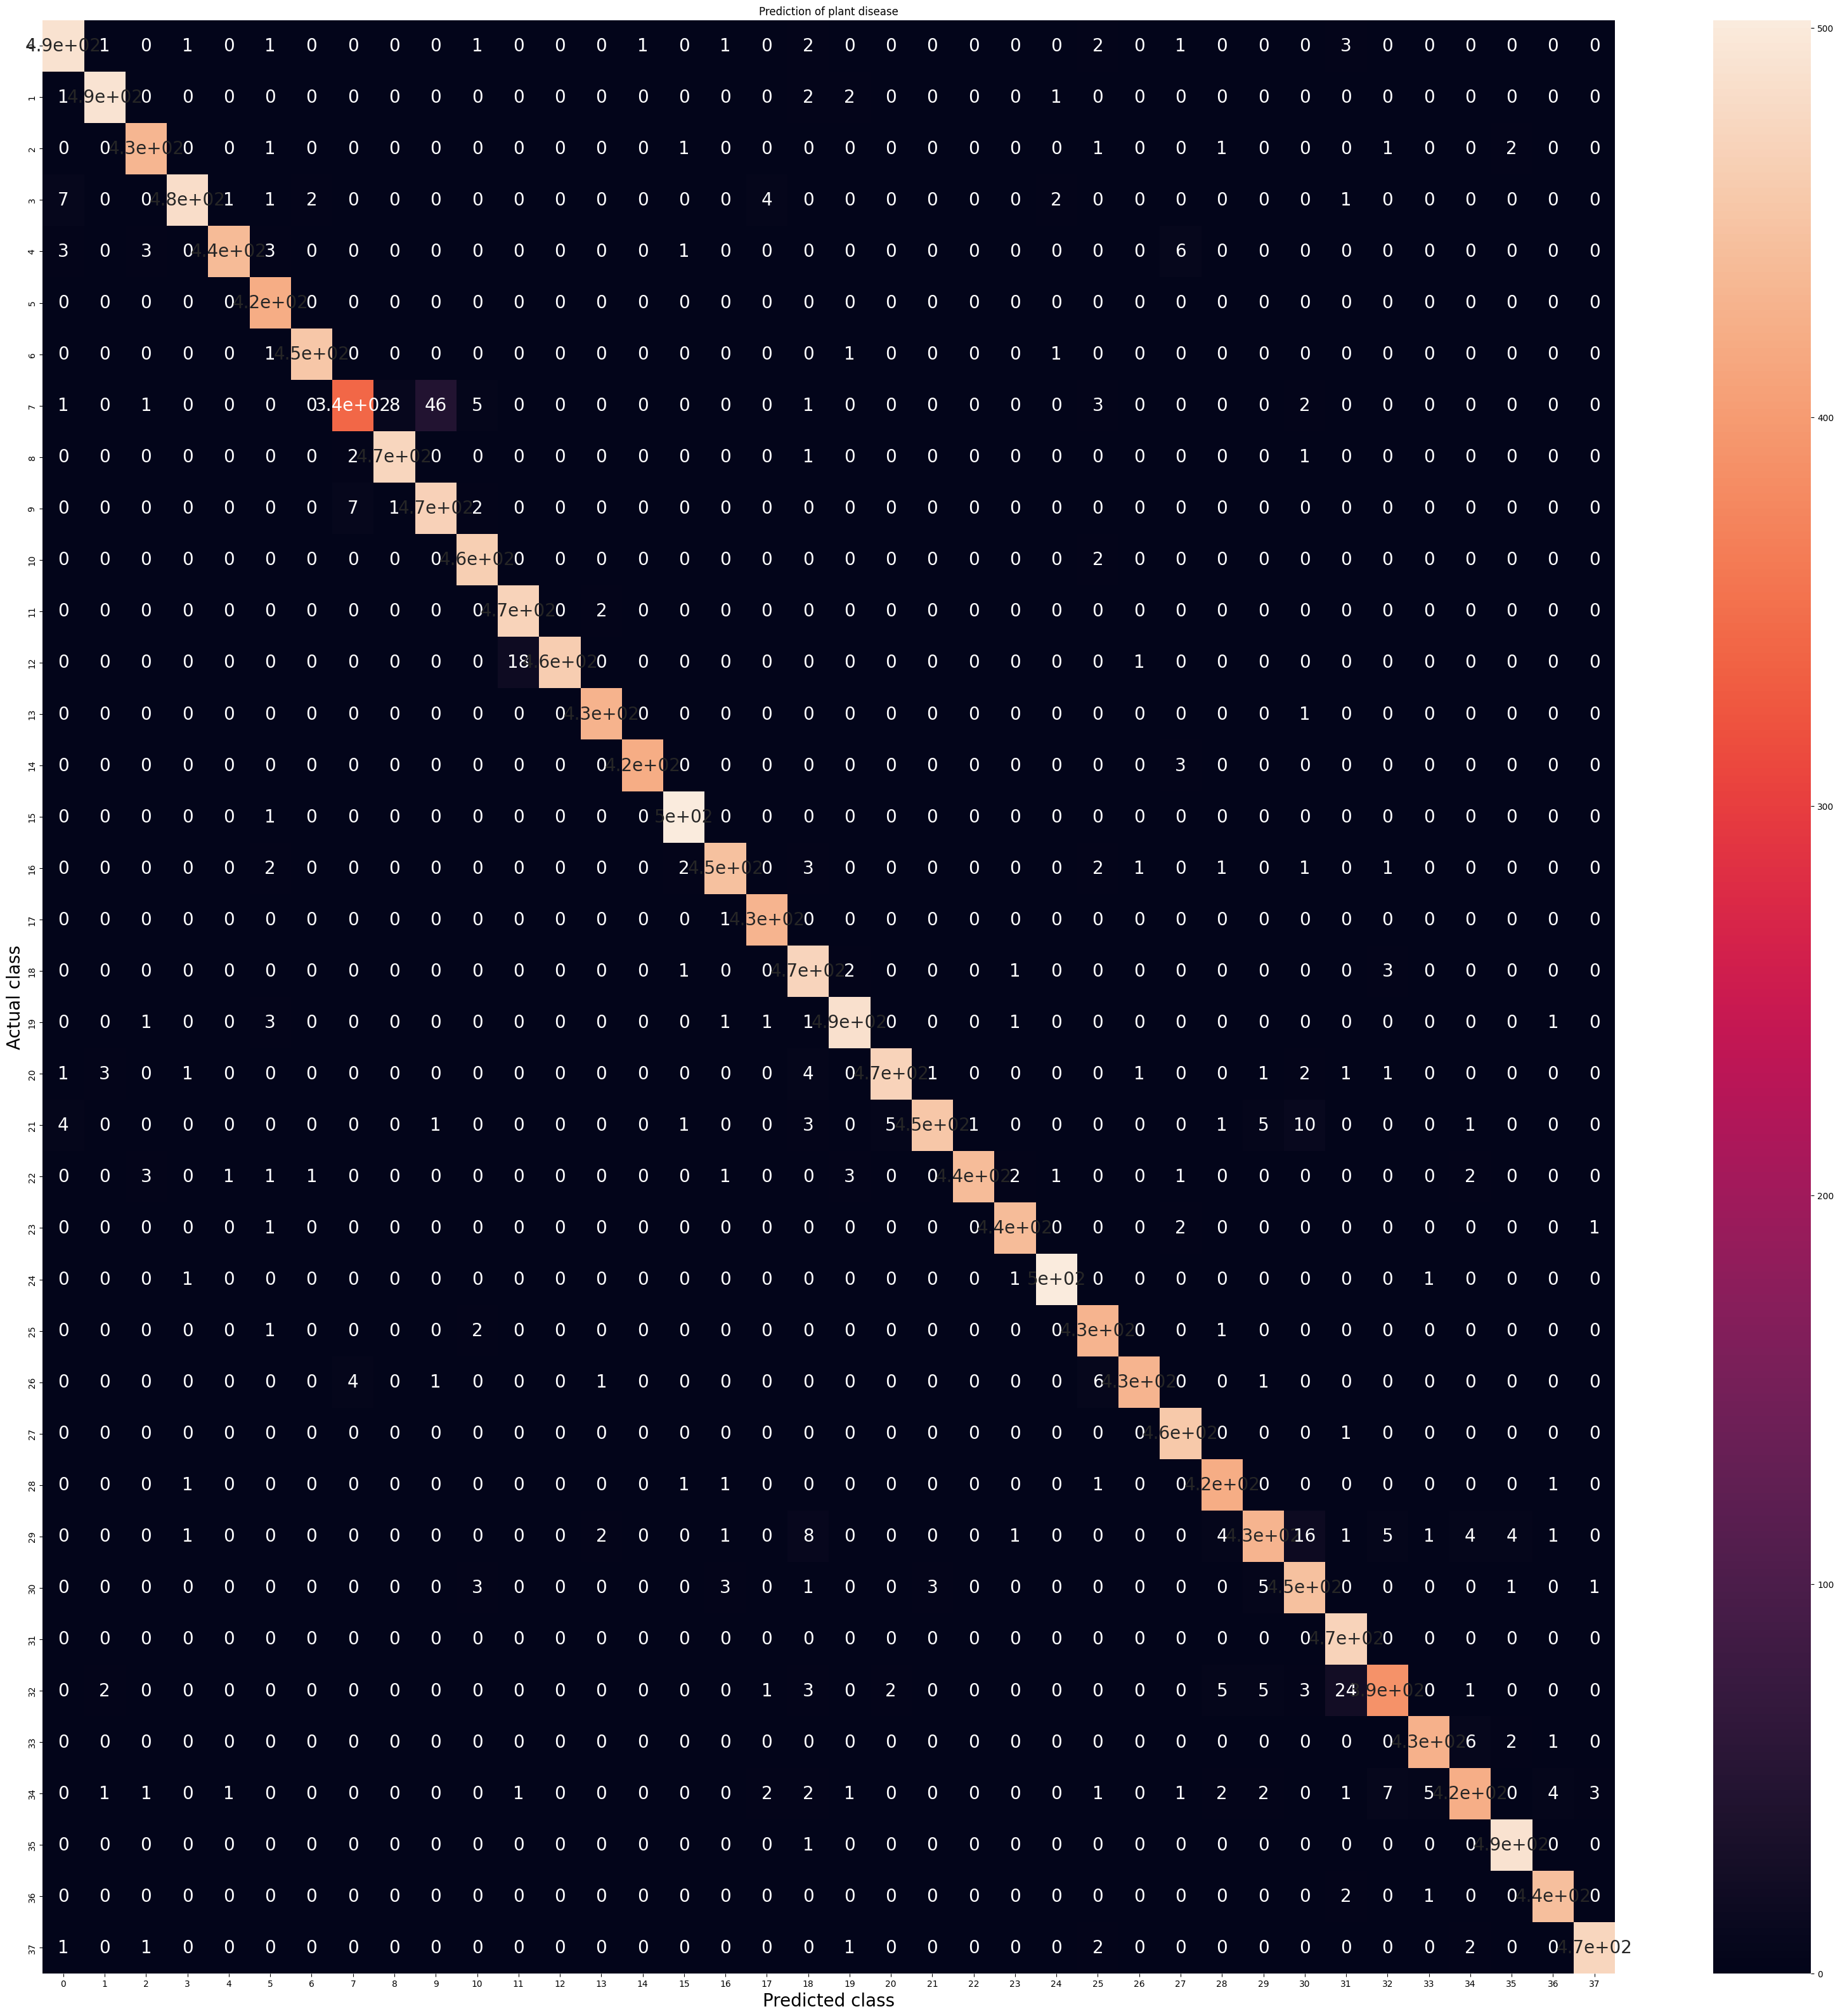

In [36]:
plt.figure(figsize=(40,40))
sns.heatmap(cn,annot=True,annot_kws={'size':20})
plt.xlabel("Predicted class",fontsize=20)
plt.ylabel("Actual class",fontsize=20)
plt.title("Prediction of plant disease")
plt.show()

In [37]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,528,288 (89.75 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,685,526 (59.84 MB)

#Testing on real image

In [38]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#visualising single image

In [54]:
import cv2
image_path = "/content/test/test/CornCommonRust1.JPG"

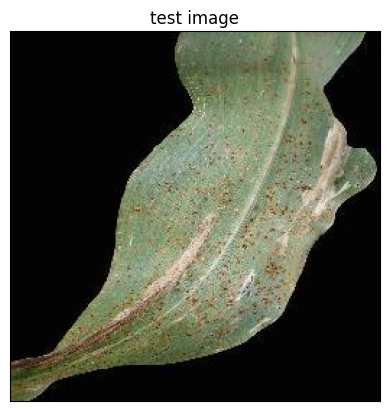

In [55]:
#reading image
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #convert BGR to RGB image
#Displaying image
plt.imshow(img)
plt.title("test image")
plt.xticks([])
plt.yticks([])
plt.show()

Testing model

In [56]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr]) # converting single image into batch
print(input_arr.shape)

(1, 128, 128, 3)


In [57]:
prediction = model.predict(input_arr)
prediction,prediction.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


(array([[1.43326268e-10, 1.33138655e-14, 1.04967933e-15, 7.45501242e-18,
         8.24311394e-16, 1.87269720e-16, 4.36587482e-17, 7.45430922e-16,
         9.99999881e-01, 1.68761976e-15, 3.72763106e-15, 4.95805137e-23,
         9.58180999e-19, 2.39322570e-23, 2.71003950e-23, 2.91435251e-17,
         4.96029401e-19, 6.13171152e-20, 1.71027201e-13, 1.74438071e-16,
         6.62062974e-14, 4.16535814e-25, 1.16656876e-17, 1.98099855e-23,
         2.30620297e-21, 1.15264310e-18, 2.33184324e-18, 4.36634688e-22,
         6.53209798e-22, 1.10967065e-18, 1.13415190e-07, 1.81767778e-17,
         2.58782171e-16, 1.76684058e-26, 2.83020525e-20, 1.13381392e-23,
         1.60096708e-22, 3.62520951e-19]], dtype=float32),
 (1, 38))

In [58]:
result_index = np.argmax(prediction)
result_index

np.int64(8)

In [52]:
class_name = ['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

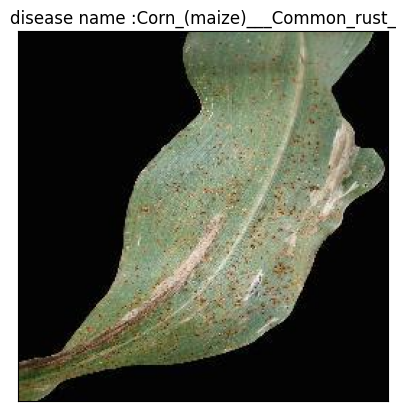

In [59]:
#displaying result of disease prediction
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"disease name :{model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()